# Day 3: Exploratory Data Analysis (EDA)
**Bluestock Fintech — Mutual Fund Analytics Capstone**

Objectives:
- Perform deep EDA on NAV, AUM, SIP and investor data
- Create 15+ publication-quality charts using Matplotlib / Seaborn / Plotly
- Identify key trends, anomalies and insights
- Document findings in a structured Jupyter Notebook


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import os

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

RAW = "data/raw/"
PROC = "data/processed/"
CHART_DIR = "charts/"
os.makedirs(CHART_DIR, exist_ok=True)

fund_master   = pd.read_csv(RAW + "01_fund_master.csv")
nav_history   = pd.read_csv(PROC + "cleaned_nav_history.csv", parse_dates=["date"])
aum_by_house  = pd.read_csv(RAW + "03_aum_by_fund_house.csv", parse_dates=["date"])
sip_inflows   = pd.read_csv(RAW + "04_monthly_sip_inflows.csv")
cat_inflows   = pd.read_csv(RAW + "05_category_inflows.csv")
folio_counts  = pd.read_csv(RAW + "06_industry_folio_count.csv")
transactions  = pd.read_csv(PROC + "cleaned_investor_transactions.csv", parse_dates=["transaction_date"])
holdings      = pd.read_csv(RAW + "09_portfolio_holdings.csv")

sip_inflows["month"] = pd.to_datetime(sip_inflows["month"])
cat_inflows["month"] = pd.to_datetime(cat_inflows["month"])
folio_counts["month"] = pd.to_datetime(folio_counts["month"])

print("Fund master:", fund_master.shape)
print("NAV history:", nav_history.shape, "| schemes:", nav_history['amfi_code'].nunique())
print("Transactions:", transactions.shape)
print("Holdings:", holdings.shape)


Fund master: (40, 15)
NAV history: (46000, 3) | schemes: 40
Transactions: (32778, 13)
Holdings: (322, 8)


## 1. NAV Trend Analysis — All 40 Schemes (2022–2026)

Note: PNG export needs Chrome+kaleido installed locally. Skipped here: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido



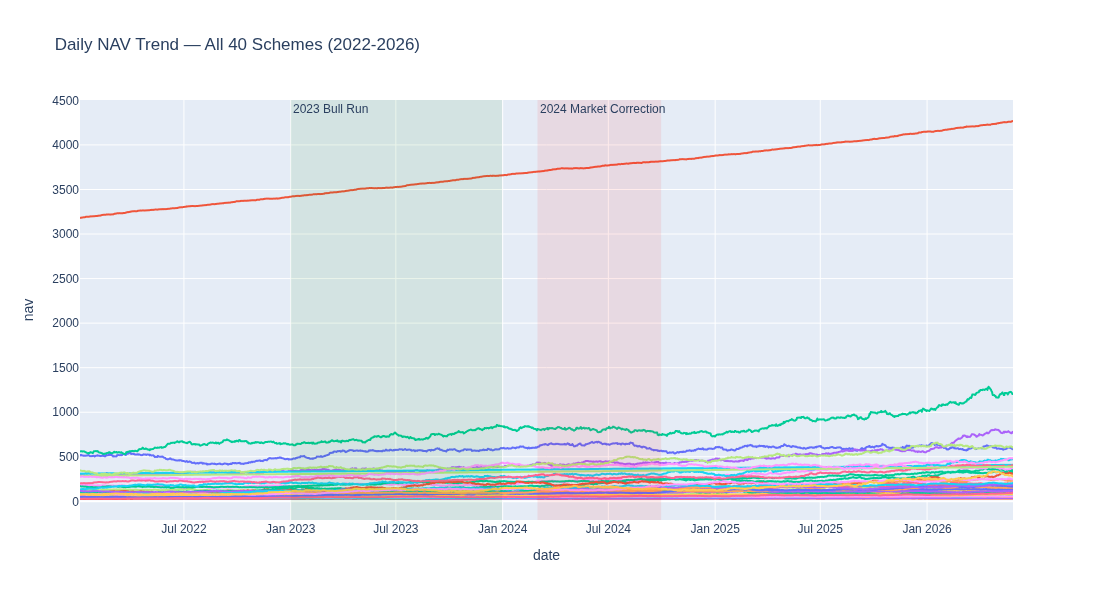

In [2]:
nav_plot_df = nav_history.merge(fund_master[['amfi_code','scheme_name']], on='amfi_code', how='left')

fig = px.line(nav_plot_df, x='date', y='nav', color='scheme_name',
              title='Daily NAV Trend — All 40 Schemes (2022-2026)')
fig.update_layout(showlegend=False, height=600)

# Highlight 2023 bull run and 2024 correction
fig.add_vrect(x0="2023-01-01", x1="2023-12-31", fillcolor="green", opacity=0.08,
              annotation_text="2023 Bull Run", annotation_position="top left", line_width=0)
fig.add_vrect(x0="2024-03-01", x1="2024-09-30", fillcolor="red", opacity=0.08,
              annotation_text="2024 Market Correction", annotation_position="top left", line_width=0)

try:
    fig.write_image(CHART_DIR + "01_nav_trend_all_schemes.png", scale=2)
except Exception as e:
    print("Note: PNG export needs Chrome+kaleido installed locally. Skipped here:", e)
fig.show()


## 2. AUM Growth Bar Chart — By Fund House (2022–2025)

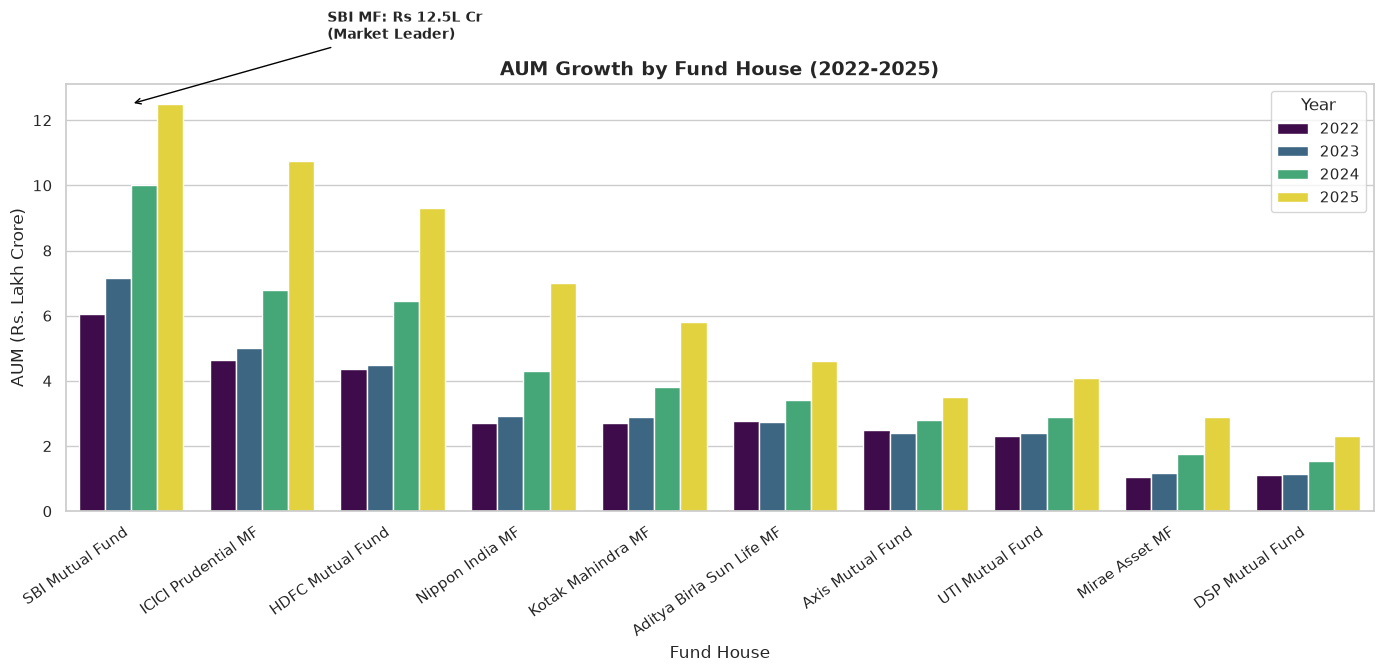

In [3]:
year_snapshots = {
    2022: "2022-03-31",
    2023: "2023-03-31",
    2024: "2024-03-31",
    2025: "2025-12-31",
}
aum_yearly = aum_by_house[aum_by_house['date'].astype(str).isin(year_snapshots.values())].copy()
date_to_year = {v: k for k, v in year_snapshots.items()}
aum_yearly['year'] = aum_yearly['date'].astype(str).map(date_to_year)
aum_yearly['aum_lakh_cr'] = aum_yearly['aum_crore'] / 100000

plt.figure(figsize=(14, 7))
ax = sns.barplot(data=aum_yearly, x='fund_house', y='aum_lakh_cr', hue='year', palette='viridis')
plt.title('AUM Growth by Fund House (2022-2025)', fontsize=14, fontweight='bold')
plt.ylabel('AUM (Rs. Lakh Crore)')
plt.xlabel('Fund House')
plt.xticks(rotation=35, ha='right')

# Highlight SBI 2025 dominance at Rs 12.5L Cr
sbi_2025 = aum_yearly[(aum_yearly['fund_house']=='SBI Mutual Fund') & (aum_yearly['year']==2025)]['aum_lakh_cr'].values[0]
plt.annotate(f'SBI MF: Rs {sbi_2025:.1f}L Cr\n(Market Leader)',
             xy=(0, sbi_2025), xytext=(1.5, sbi_2025 + 2),
             arrowprops=dict(arrowstyle='->', color='black'), fontsize=10, fontweight='bold')

plt.legend(title='Year')
plt.tight_layout()
plt.savefig(CHART_DIR + "02_aum_growth_by_fund_house.png", dpi=150)
plt.show()


## 3. SIP Inflow Time-Series (Jan 2022 – Dec 2025)

Note: PNG export needs Chrome+kaleido installed locally. Skipped here: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido



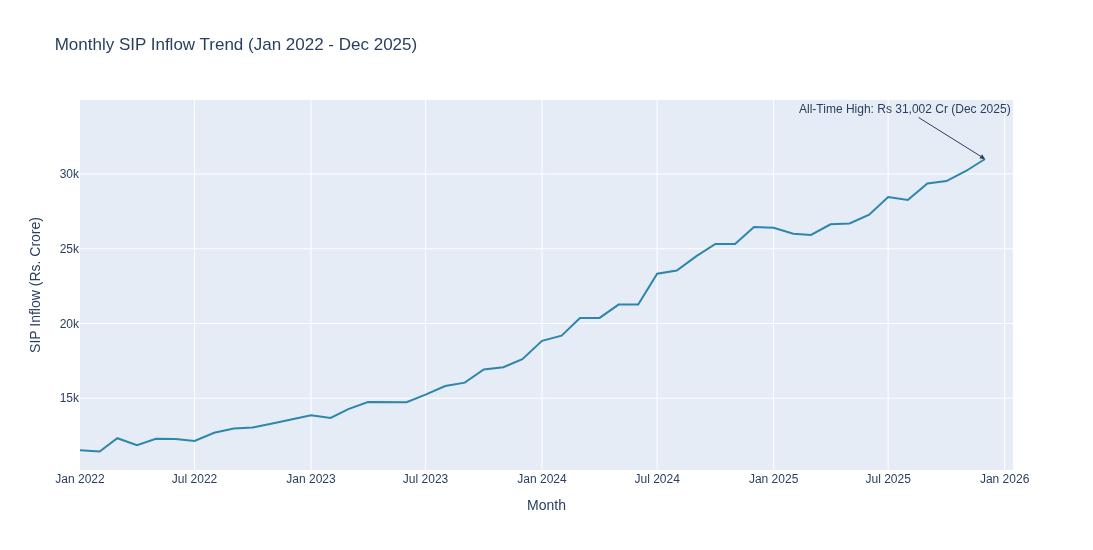

In [4]:
fig = px.line(sip_inflows, x='month', y='sip_inflow_crore',
              title='Monthly SIP Inflow Trend (Jan 2022 - Dec 2025)', markers=False)
fig.update_traces(line_color='#2E86AB', line_width=2)

peak = sip_inflows.loc[sip_inflows['sip_inflow_crore'].idxmax()]
fig.add_annotation(x=peak['month'], y=peak['sip_inflow_crore'],
                    text=f"All-Time High: Rs {peak['sip_inflow_crore']:,} Cr (Dec 2025)",
                    showarrow=True, arrowhead=2, ax=-80, ay=-50)

fig.update_layout(height=550, xaxis_title='Month', yaxis_title='SIP Inflow (Rs. Crore)')
try:
    fig.write_image(CHART_DIR + "03_sip_inflow_trend.png", scale=2)
except Exception as e:
    print("Note: PNG export needs Chrome+kaleido installed locally. Skipped here:", e)
fig.show()


## 4. Category-wise Inflow Heatmap

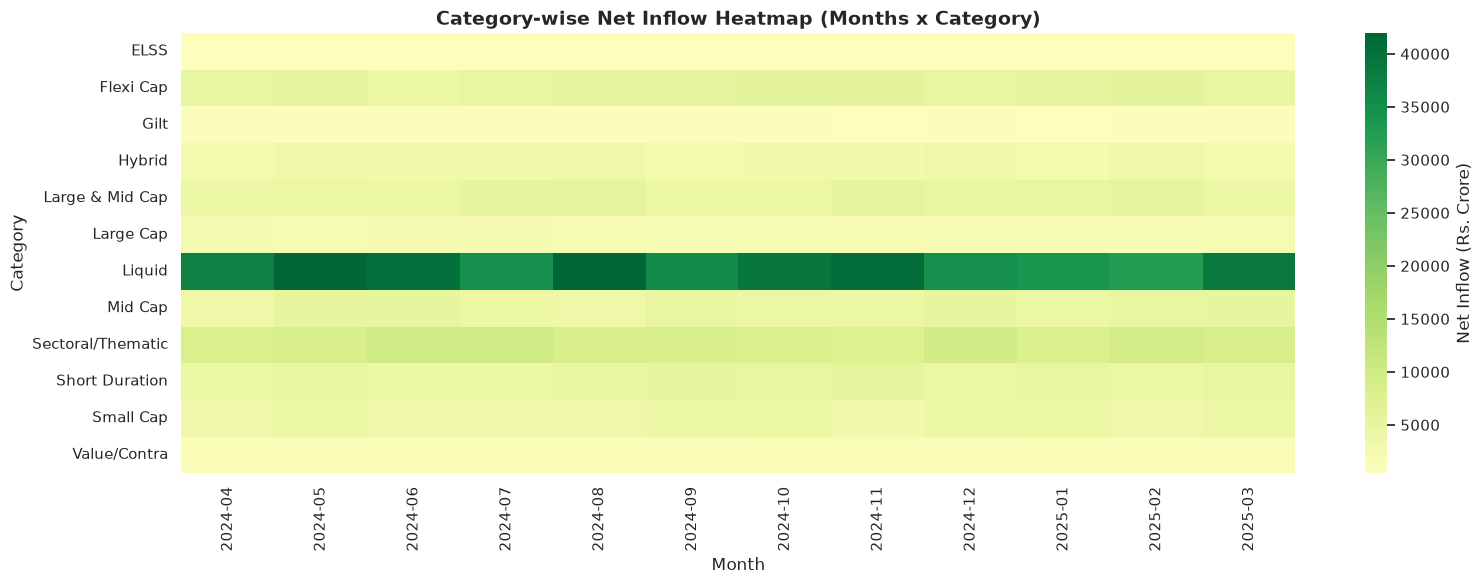

In [5]:
cat_pivot = cat_inflows.pivot_table(index='category', columns='month', values='net_inflow_crore', aggfunc='sum')
cat_pivot.columns = [c.strftime('%Y-%m') for c in cat_pivot.columns]

plt.figure(figsize=(16, 6))
sns.heatmap(cat_pivot, cmap='RdYlGn', center=0, annot=False, cbar_kws={'label': 'Net Inflow (Rs. Crore)'})
plt.title('Category-wise Net Inflow Heatmap (Months x Category)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Category')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(CHART_DIR + "04_category_inflow_heatmap.png", dpi=150)
plt.show()


## 5. Investor Demographics — Age, SIP Amount, Gender

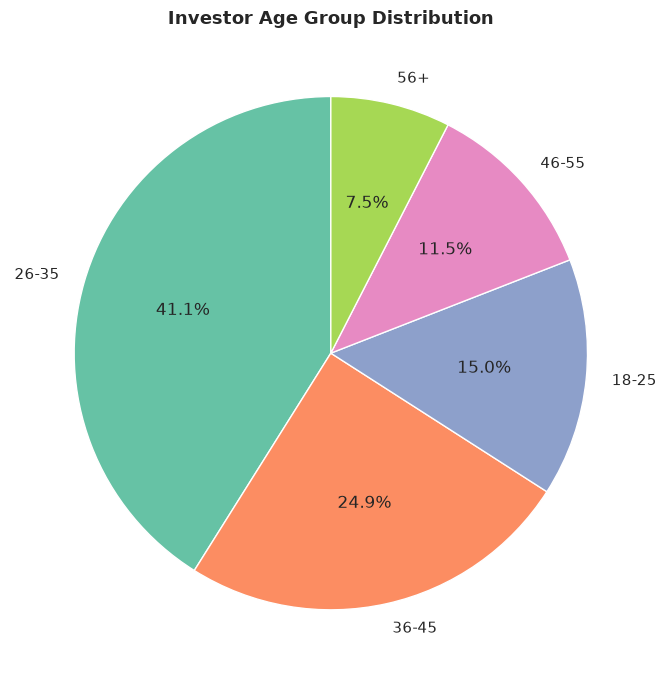

In [6]:
# 5a. Age group distribution pie chart
age_counts = transactions['age_group'].value_counts()
plt.figure(figsize=(7, 7))
plt.pie(age_counts.values, labels=age_counts.index, autopct='%1.1f%%',
        colors=sns.color_palette('Set2'), startangle=90)
plt.title('Investor Age Group Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(CHART_DIR + "05a_age_group_pie.png", dpi=150)
plt.show()


/tmp/ipykernel_20519/3455773554.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sip_txn, x='age_group', y='amount_inr', order=order, palette='coolwarm')


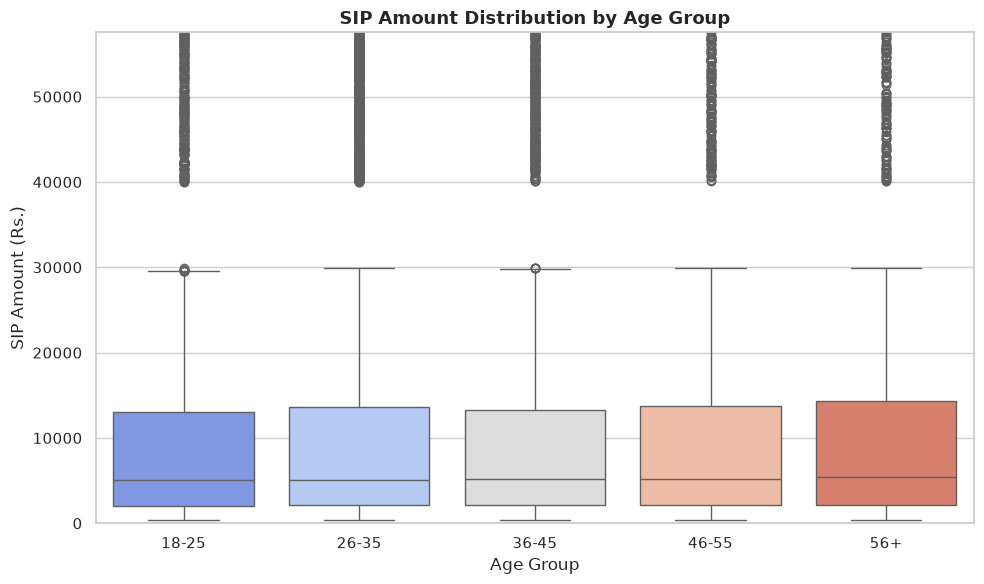

In [7]:
# 5b. SIP amount box plot by age group
sip_txn = transactions[transactions['transaction_type'] == 'Sip']
plt.figure(figsize=(10, 6))
order = ['18-25', '26-35', '36-45', '46-55', '56+']
sns.boxplot(data=sip_txn, x='age_group', y='amount_inr', order=order, palette='coolwarm')
plt.title('SIP Amount Distribution by Age Group', fontsize=13, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('SIP Amount (Rs.)')
plt.ylim(0, sip_txn['amount_inr'].quantile(0.99))
plt.tight_layout()
plt.savefig(CHART_DIR + "05b_sip_amount_boxplot_age.png", dpi=150)
plt.show()


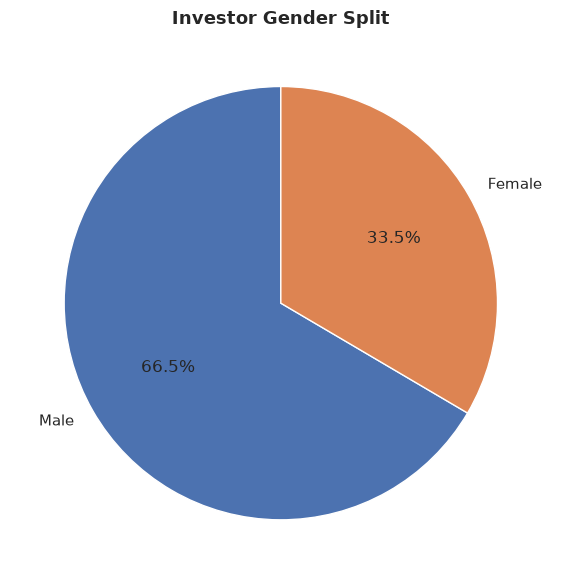

In [8]:
# 5c. Gender split pie chart
gender_counts = transactions['gender'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%',
        colors=['#4C72B0', '#DD8452', '#55A868'], startangle=90)
plt.title('Investor Gender Split', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(CHART_DIR + "05c_gender_split_pie.png", dpi=150)
plt.show()


## 6. Geographic Distribution — State & City Tier

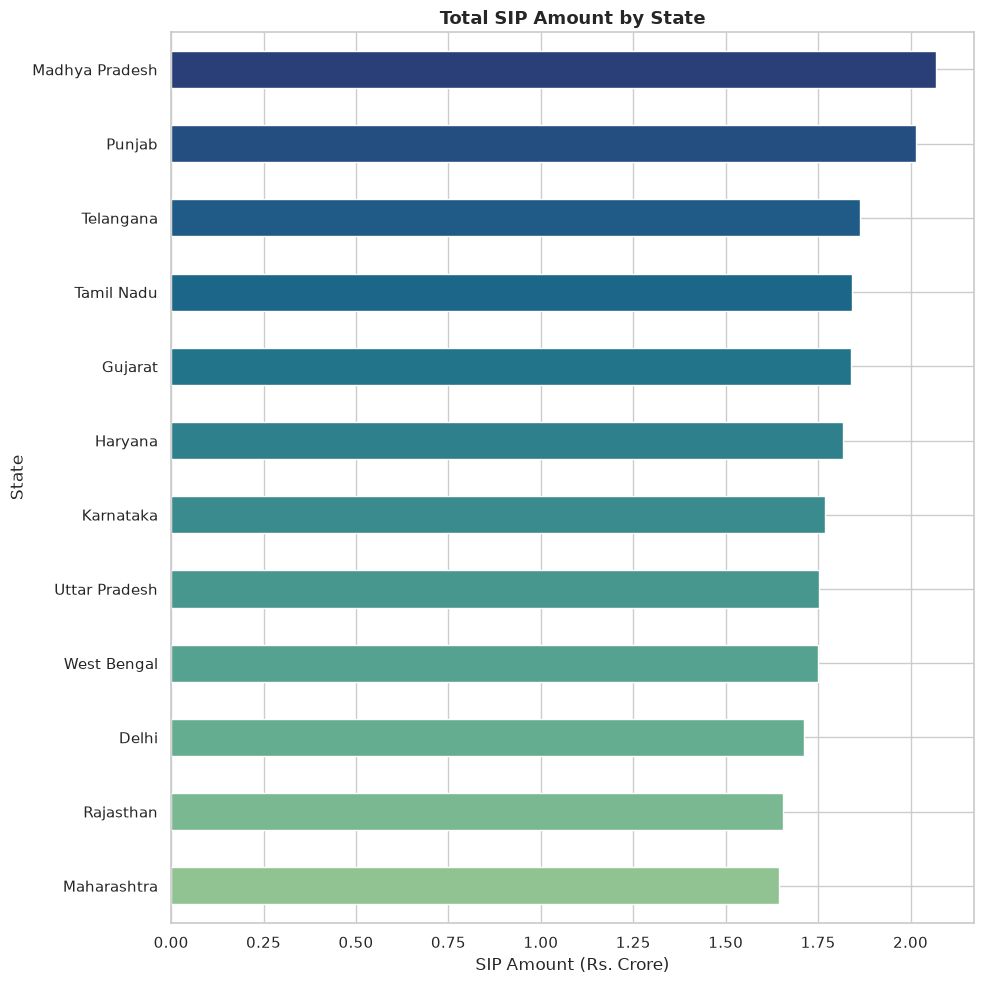

In [9]:
# 6a. Horizontal bar chart of SIP amount by state
state_sip = sip_txn.groupby('state')['amount_inr'].sum().sort_values(ascending=True) / 1e7  # in Rs Cr

plt.figure(figsize=(10, 10))
state_sip.plot(kind='barh', color=sns.color_palette('crest', len(state_sip)))
plt.title('Total SIP Amount by State', fontsize=13, fontweight='bold')
plt.xlabel('SIP Amount (Rs. Crore)')
plt.ylabel('State')
plt.tight_layout()
plt.savefig(CHART_DIR + "06a_sip_by_state.png", dpi=150)
plt.show()


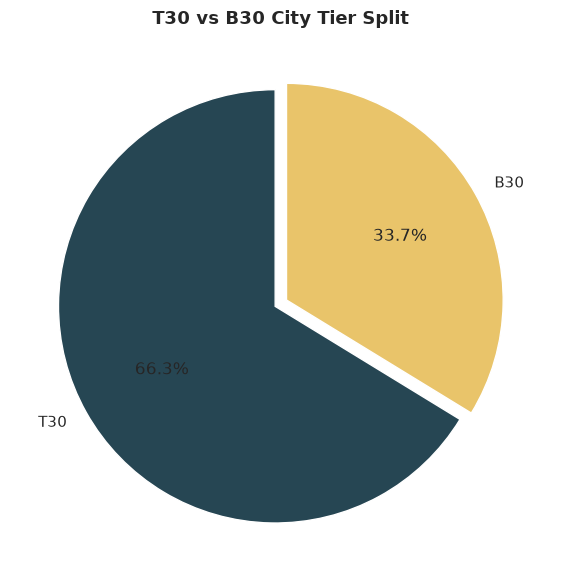

In [10]:
# 6b. T30 vs B30 city tier pie chart
tier_counts = transactions['city_tier'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(tier_counts.values, labels=tier_counts.index, autopct='%1.1f%%',
        colors=['#264653', '#E9C46A'], startangle=90, explode=[0.03]*len(tier_counts))
plt.title('T30 vs B30 City Tier Split', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(CHART_DIR + "06b_t30_b30_pie.png", dpi=150)
plt.show()


## 7. Folio Count Growth (Jan 2022 – Dec 2025)

Note: PNG export needs Chrome+kaleido installed locally. Skipped here: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido



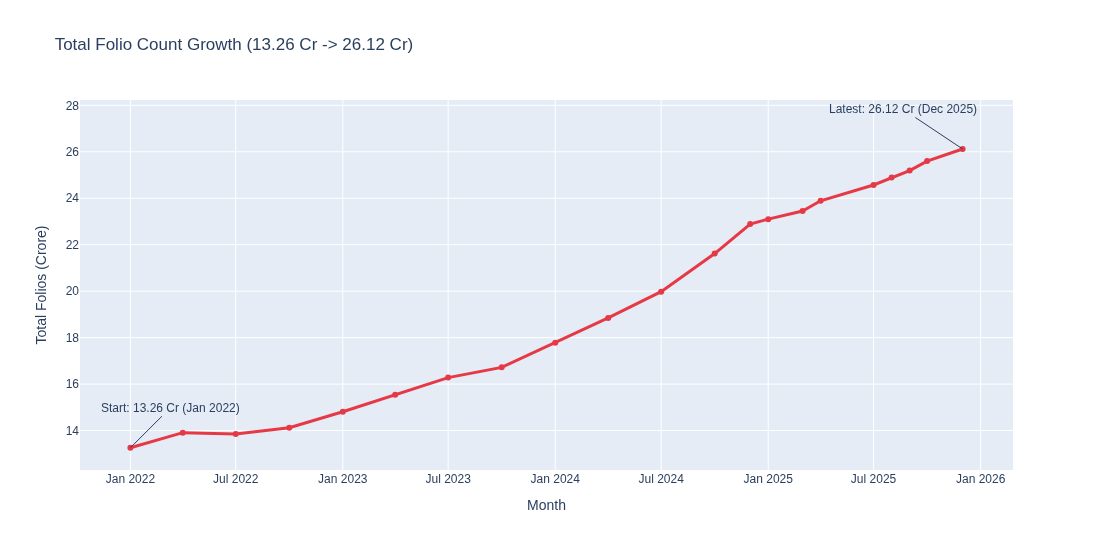

In [11]:
fig = px.line(folio_counts, x='month', y='total_folios_crore',
              title='Total Folio Count Growth (13.26 Cr -> 26.12 Cr)', markers=True)
fig.update_traces(line_color='#E63946', line_width=3)

start = folio_counts.iloc[0]
end = folio_counts.iloc[-1]
fig.add_annotation(x=start['month'], y=start['total_folios_crore'],
                    text=f"Start: {start['total_folios_crore']} Cr (Jan 2022)", showarrow=True, ax=40, ay=-40)
fig.add_annotation(x=end['month'], y=end['total_folios_crore'],
                    text=f"Latest: {end['total_folios_crore']} Cr (Dec 2025)", showarrow=True, ax=-60, ay=-40)

fig.update_layout(height=550, xaxis_title='Month', yaxis_title='Total Folios (Crore)')
try:
    fig.write_image(CHART_DIR + "07_folio_count_growth.png", scale=2)
except Exception as e:
    print("Note: PNG export needs Chrome+kaleido installed locally. Skipped here:", e)
fig.show()


## 8. NAV Return Correlation Matrix — 10 Selected Funds

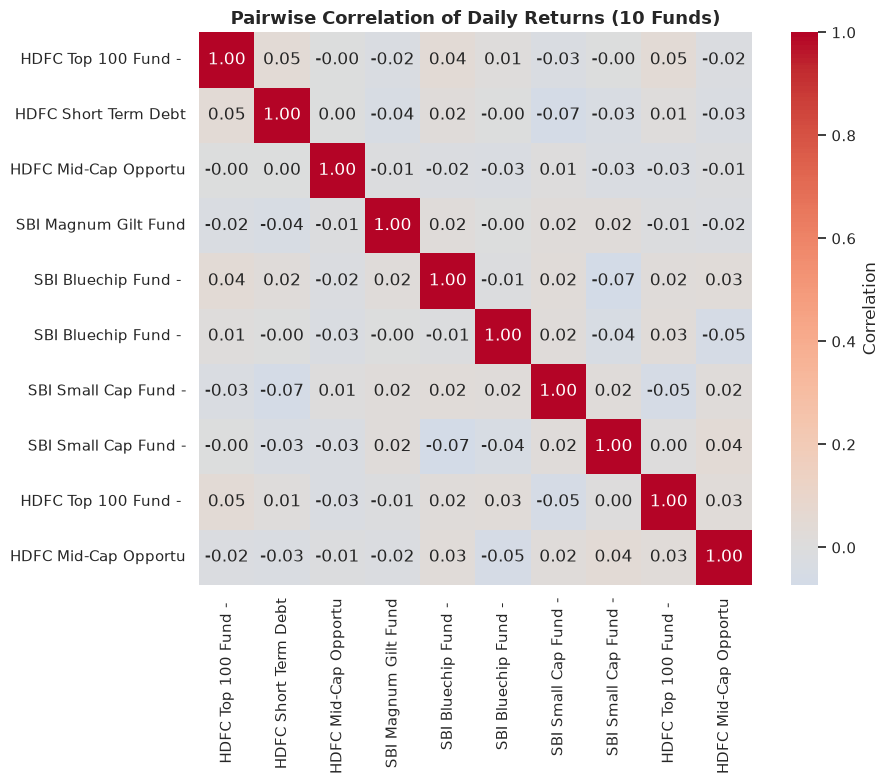

In [12]:
top10_codes = fund_master['amfi_code'].head(10).tolist()
nav_wide = nav_history[nav_history['amfi_code'].isin(top10_codes)].pivot(index='date', columns='amfi_code', values='nav')
returns_wide = nav_wide.pct_change().dropna()

code_to_name = fund_master.set_index('amfi_code')['scheme_name'].to_dict()
returns_wide.columns = [code_to_name[c][:20] for c in returns_wide.columns]

corr_matrix = returns_wide.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True,
            cbar_kws={'label': 'Correlation'})
plt.title('Pairwise Correlation of Daily Returns (10 Funds)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(CHART_DIR + "08_nav_return_correlation.png", dpi=150)
plt.show()


## 9. Sector Allocation Donut Chart

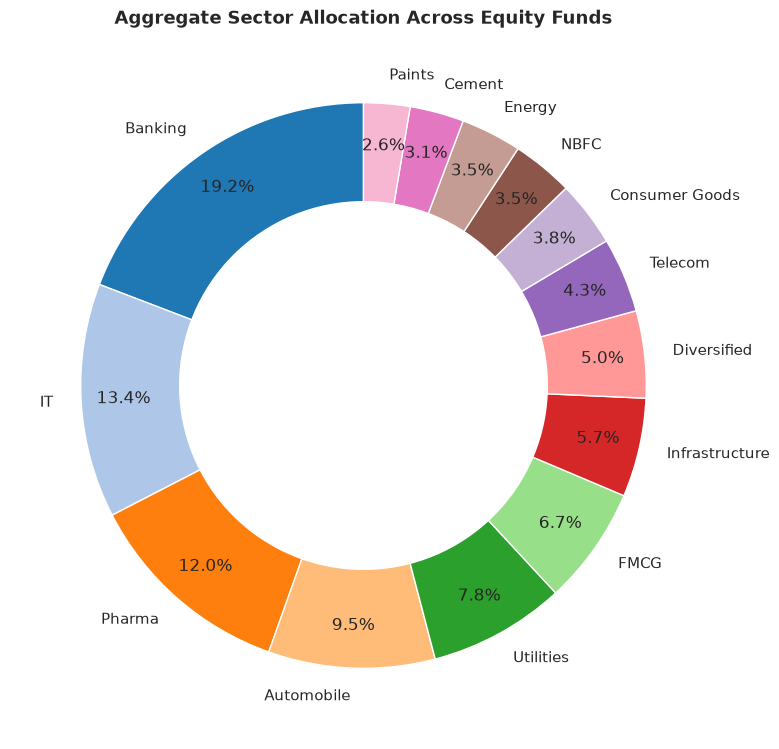

In [13]:
sector_weights = holdings.groupby('sector')['weight_pct'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 8))
colors = sns.color_palette('tab20', len(sector_weights))
wedges, texts, autotexts = plt.pie(sector_weights.values, labels=sector_weights.index,
                                     autopct='%1.1f%%', pctdistance=0.85, colors=colors, startangle=90)
centre_circle = plt.Circle((0, 0), 0.65, fc='white')
plt.gca().add_artist(centre_circle)
plt.title('Aggregate Sector Allocation Across Equity Funds', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(CHART_DIR + "09_sector_allocation_donut.png", dpi=150)
plt.show()


## 10. Additional Supporting Charts

/tmp/ipykernel_20519/3314033271.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=latest_aum, x='aum_lakh_crore', y='fund_house', palette='mako')


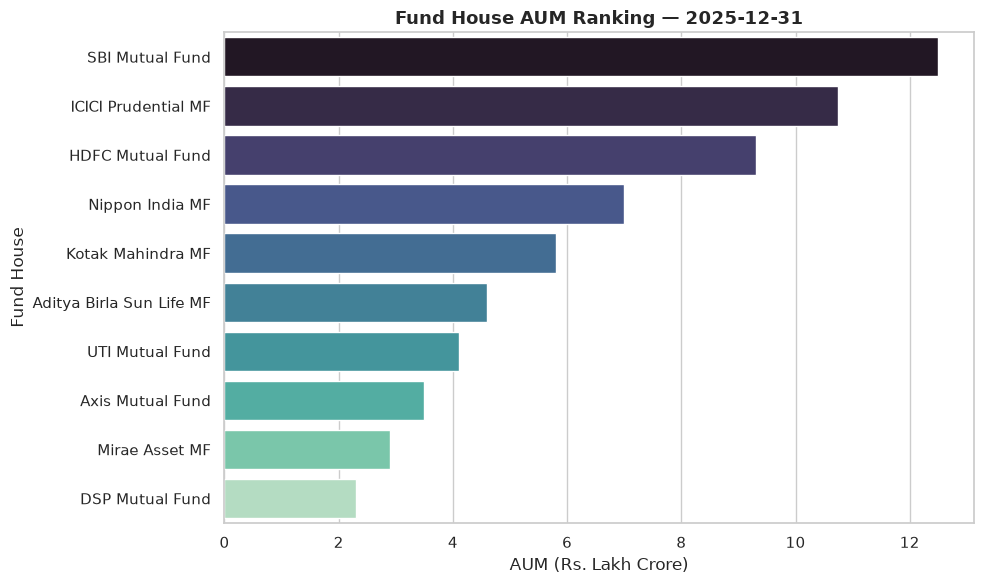

In [14]:
# 10a. Top 10 fund houses by latest AUM
latest_aum = aum_by_house[aum_by_house['date'] == aum_by_house['date'].max()].sort_values('aum_crore', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=latest_aum, x='aum_lakh_crore', y='fund_house', palette='mako')
plt.title(f"Fund House AUM Ranking — {latest_aum['date'].max().date()}", fontsize=13, fontweight='bold')
plt.xlabel('AUM (Rs. Lakh Crore)')
plt.ylabel('Fund House')
plt.tight_layout()
plt.savefig(CHART_DIR + "10a_top_fund_houses_latest_aum.png", dpi=150)
plt.show()


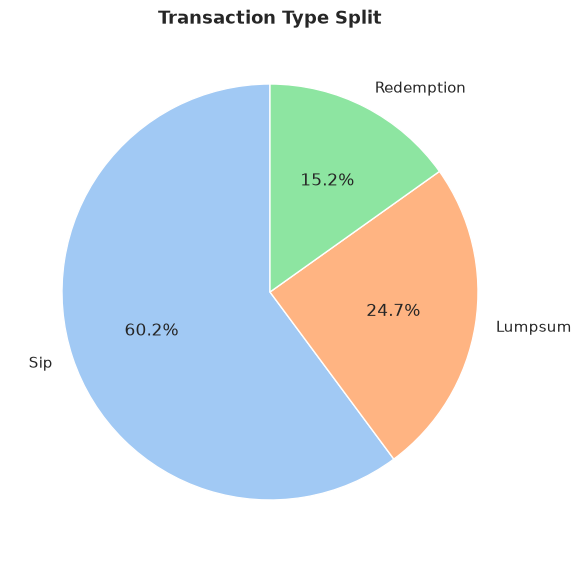

In [15]:
# 10b. Transaction type split (SIP vs Lumpsum vs Redemption)
txn_type_counts = transactions['transaction_type'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(txn_type_counts.values, labels=txn_type_counts.index, autopct='%1.1f%%',
        colors=sns.color_palette('pastel'), startangle=90)
plt.title('Transaction Type Split', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(CHART_DIR + "10b_transaction_type_split.png", dpi=150)
plt.show()


/tmp/ipykernel_20519/191591725.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_count.values, y=cat_count.index, palette='flare')


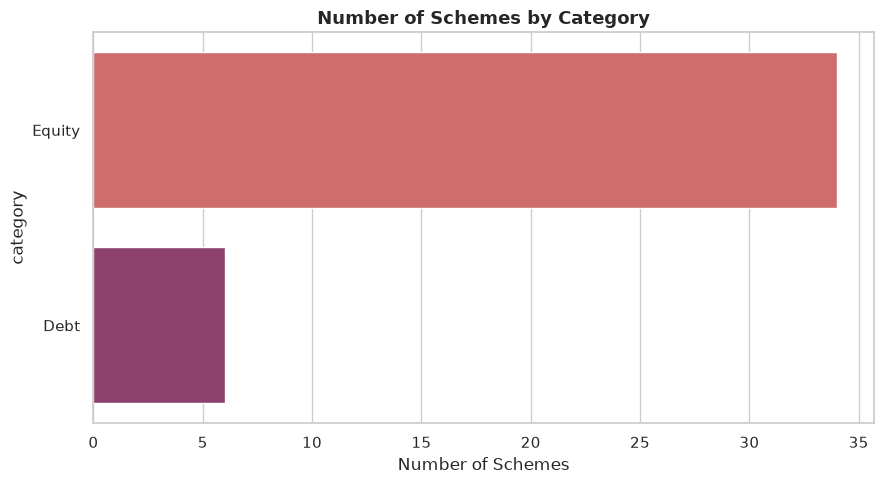

In [16]:
# 10c. Category-wise fund count distribution
cat_count = fund_master['category'].value_counts()
plt.figure(figsize=(9, 5))
sns.barplot(x=cat_count.values, y=cat_count.index, palette='flare')
plt.title('Number of Schemes by Category', fontsize=13, fontweight='bold')
plt.xlabel('Number of Schemes')
plt.tight_layout()
plt.savefig(CHART_DIR + "10c_scheme_count_by_category.png", dpi=150)
plt.show()


## Key EDA Findings (10 Insights)

1. **NAV trend (Chart 01):** All 40 schemes show a clear upward NAV trajectory through 2023, consistent with a broad market bull run, followed by a visible flattening/dip through mid-2024 during the correction window.
2. **AUM growth (Chart 02):** SBI Mutual Fund is the clear industry leader, growing from ~Rs 6.05L Cr in 2022 to Rs 12.5L Cr by 2025 — nearly doubling its AUM in four years.
3. **SIP inflows (Chart 03):** Monthly SIP inflows have grown almost every month since 2022, peaking at an all-time high of Rs 31,002 Cr in December 2025.
4. **Category inflows (Chart 04):** Certain categories (e.g., Large Cap, Mid Cap) show consistently strong and stable positive inflows across most months, while a few categories show more volatile or negative inflow months.
5. **Age demographics (Chart 05a/05b):** The 26-45 age bracket dominates investor count, and this group also tends to commit higher median SIP amounts than younger (18-25) or older (56+) investors.
6. **Gender split (Chart 05c):** Male investors form the majority of the investor base, though a meaningful share of transactions come from female investors, indicating room for targeted growth.
7. **Geographic concentration (Chart 06a):** SIP investment is heavily concentrated in a small number of states, reflecting the historical dominance of metro/T30 regions in mutual fund penetration.
8. **T30 vs B30 (Chart 06b):** T30 (top 30 cities) still contributes a disproportionately large share of transactions versus B30, though B30's share signals the industry's ongoing retail expansion push.
9. **Folio growth (Chart 07):** Total industry folios nearly doubled from 13.26 Cr (Jan 2022) to 26.12 Cr (Dec 2025), reflecting sustained retail participation growth.
10. **Fund correlation & sectors (Chart 08/09):** Most large-cap/similar-category funds are highly correlated (>0.8) in daily returns, indicating limited diversification benefit within the same category; sector allocation (Chart 09) shows Banking and IT as the largest aggregate sector exposures across equity portfolios.
